In [1]:
import torch
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda")

# Dataset and dataloader

In [2]:
ls data

MNIST/


In [3]:
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision import datasets


training_data = datasets.MNIST(
    root="data",
    train=True,
    download=False,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=ToTensor()
)

batch_size = 512
train_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_data,  batch_size=batch_size, shuffle=False)

training data shape: torch.Size([60000, 28, 28])
example pic 666


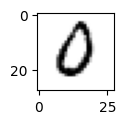

In [4]:
print(f"training data shape: {training_data.data.shape}")
print(f"example pic {(_idx := 666)}")
plt.figure(figsize=(1,1)); plt.imshow(training_data.data[_idx], cmap="Greys"); plt.show()

# Model

In [5]:
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, latent_dim)
        self.Leaky_ReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h_ = self.Leaky_ReLU(self.FC_input(x))
        h_ = self.Leaky_ReLU(self.FC_hidden(h_))
        h_ = self.FC_hidden2(h_)
        return h_

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.FC_hidden2 = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.LeakyReLU(self.FC_hidden2(x))
        h = self.LeakyReLU(self.FC_hidden(h))
        h = self.FC_output(h)
        return h

class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super().__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def forward(self, x):
        return self.Decoder(self.Encoder(x))

In [6]:
hidden_dim = 400
latent_dim = 64
x_dim = training_data.data.shape[1] * training_data.data.shape[2]
encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)
model = Model(Encoder=encoder, Decoder=decoder).to(DEVICE)

# Training

In [7]:
from torch.optim import Adam

lr = 1e-3
BCE_loss = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=lr)

print("Start training VAE..")
model.train()
epochs = 30
for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)

        optimizer.zero_grad()
        x_hat = model(x)
        loss = BCE_loss(x_hat, x)

        overall_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"\tEpoch {epoch + 1} complete. Average Loss: {overall_loss / len(train_loader):.5f}") 
print("Finish!!")

Start training VAE..
	Epoch 1 complete. Average Loss: 0.28268
	Epoch 2 complete. Average Loss: 0.18013
	Epoch 3 complete. Average Loss: 0.14283
	Epoch 4 complete. Average Loss: 0.12415
	Epoch 5 complete. Average Loss: 0.11055
	Epoch 6 complete. Average Loss: 0.10221
	Epoch 7 complete. Average Loss: 0.09696
	Epoch 8 complete. Average Loss: 0.09261
	Epoch 9 complete. Average Loss: 0.08960
	Epoch 10 complete. Average Loss: 0.08737
	Epoch 11 complete. Average Loss: 0.08560
	Epoch 12 complete. Average Loss: 0.08413
	Epoch 13 complete. Average Loss: 0.08281
	Epoch 14 complete. Average Loss: 0.08175
	Epoch 15 complete. Average Loss: 0.08080
	Epoch 16 complete. Average Loss: 0.07990
	Epoch 17 complete. Average Loss: 0.07914
	Epoch 18 complete. Average Loss: 0.07844
	Epoch 19 complete. Average Loss: 0.07779
	Epoch 20 complete. Average Loss: 0.07719
	Epoch 21 complete. Average Loss: 0.07670
	Epoch 22 complete. Average Loss: 0.07607
	Epoch 23 complete. Average Loss: 0.07565
	Epoch 24 complete. Av

# Generation

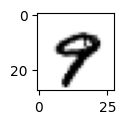

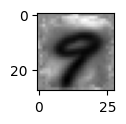

In [21]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)
        y = model(x)
        break

_idx = 9
x = x.view(batch_size, 28, 28)
y = y.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(y[_idx].cpu().numpy(), cmap="Greys"); plt.show()

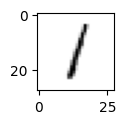

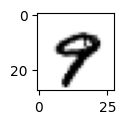

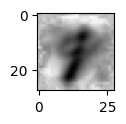

In [36]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim)
        x = x.to(DEVICE)
        y = model(x)
        break

_idx1, _idx2 = 2, 9
x = x.view(batch_size, 28, 28)
y = y.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx1].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(x[_idx2].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow((y[_idx1] + y[_idx2]).cpu().numpy(), cmap="Greys"); plt.show()

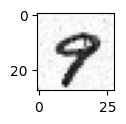

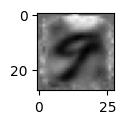

In [40]:
model.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(x.shape[0], x_dim) + torch.abs(torch.randn(x.shape[0], x_dim) * 0.1)
        x = x.to(DEVICE)
        y = model(x)
        break


_idx = 9
x = x.view(batch_size, 28, 28)
y = y.view(batch_size, 28, 28)
plt.figure(figsize=(1,1)); plt.imshow(x[_idx].cpu().numpy(), cmap="Greys"); plt.show()
plt.figure(figsize=(1,1)); plt.imshow(y[_idx].cpu().numpy(), cmap="Greys"); plt.show()